In [1]:
from mp_api.client import MPRester
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import os
load_dotenv()
MY_API_KEY = os.getenv("MP_API_KEY")

In [2]:
# Import helper functions and global vars from utils
from utils import query_materials_project, ionic_radii, compute_tolerance_factor, halides, metals

In [3]:
halide_families = [[metal, halide] for metal in metals for halide in halides]

# Query and save with date stamp when refreshing the dataset
# df = query_materials_project(MY_API_KEY, halide_families)
# After querying, save once:
# df.to_csv("../data/perovskite_dataset.csv_PLACEHOLDER_DATE", index=False)
df = pd.read_csv("../data/perovskite_dataset_6_12_2026.csv")

# Visualize our dataset and check for missing values
print(f"Found {len(df)} materials after cleaning")
print(df.head())
print("\nMissing values per column:")
print(df.isnull().sum())

Found 305 materials after cleaning
       formula  band_gap  energy_above_hull  formation_energy       volume  \
0        SnBrF    1.9941           0.231295         -1.642101   133.175737   
1  SnHg2(SBr)2    2.1758           0.132910         -0.584547  1406.327307   
2  SnHg2(SBr)2    2.3372           0.051968         -0.665489  1225.587703   
3  SnHg2(SBr)2    2.3254           0.071865         -0.645593  1283.062309   
4  SnHg2(SBr)2    1.9584           0.005744         -0.711713   851.167057   

    density  nsites  spacegroup_number  
0  5.426723       6                129  
1  3.513138      28                 14  
2  4.031227      28                 14  
3  3.850648      28                 14  
4  5.804527      28                 14  

Missing values per column:
formula              0
band_gap             0
energy_above_hull    0
formation_energy     0
volume               0
density              0
nsites               0
spacegroup_number    0
dtype: int64


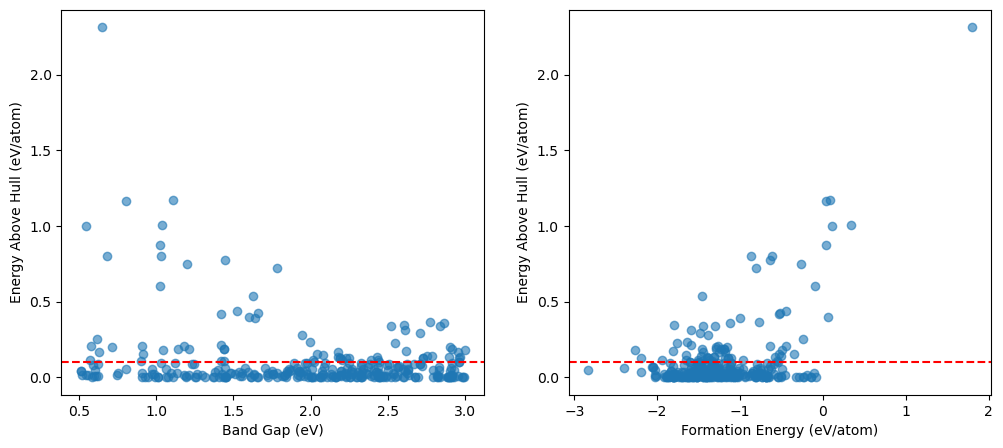

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize = (12, 5))

# Plotting Band Gap vs Stability (energy above hull)
axes[0].scatter(df["band_gap"], df["energy_above_hull"], alpha = 0.6)
axes[0].axhline(y = 0.1, color = "r", linestyle = "--")
axes[0].set_xlabel("Band Gap (eV)")
axes[0].set_ylabel("Energy Above Hull (eV/atom)")

# Plotting Formation energy vs. Stability (energy above hull)
axes[1].scatter(df["formation_energy"], df["energy_above_hull"], alpha= 0.6)
axes[1].axhline(y = 0.1, color = "r", linestyle = "--")
axes[1].set_xlabel("Formation Energy (eV/atom)")
axes[1].set_ylabel("Energy Above Hull (eV/atom)")

plt.show()

In [5]:
# Before we featurize the dataframe, we define the test compositions that we will run through the model
# We must omit these from the training set

test_compositions = ["TlPbCl3", "InPb2I5", "CsPbBr3", "TlGeCl3", "TlGeI3", "NiSn(ClO)6", "InSn2I5", "CsSnBr3", "CsPbBr3", "Pb2IOF"]

In [ ]:
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.conversions import StrToComposition

# Creates a mask to separate the test compositions from the training data
showcase_mask = df["formula"].isin(test_compositions)
df_showcase = df[showcase_mask]
df_train = df[~showcase_mask]
str_to_comp = StrToComposition()
df_train = str_to_comp.featurize_dataframe(df_train, "formula", ignore_errors=True)
ep_featurizer = ElementProperty.from_preset("magpie")
df_train = ep_featurizer.featurize_dataframe(df_train, col_id = "composition", ignore_errors=True)

StrToComposition:   0%|          | 0/291 [00:00<?, ?it/s]

ElementProperty:   0%|          | 0/291 [00:00<?, ?it/s]

For our feature cleaning step, in addition to non-numeric features, we exclude spacegroup number as the compositions we put in the test are not guaranteed to have been characterized. In fact, for the purposes of the model, we want to predict stability of material compositions that have yet to be characterized at all. Thus, because the polymorphs are not known, we cannot pass in a known spacegroup number as a feature off which we trian the model. This is also why we are excluding things like band gap, fomration energy, etc. We cannot train a dataset on these values because they would be unknown for a novel composition

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

# Cleaning non-numeric features and features that need structure to derive
exclude_cols = ["formula", "composition", "energy_above_hull", "band_gap",
"formation_energy", "volume", "density", "nsites", "spacegroup_number"]
feature_cols = [col for col in df_train.columns if col not in exclude_cols]
df_clean = df_train.dropna(subset = feature_cols  + ["energy_above_hull"])
X = df_clean[feature_cols]
y = df_clean["energy_above_hull"]
print(f"Post cleaning and featurization, we are now training on {X.shape[0]} materials with {X.shape[1]} features")

Post cleaning and featurization, we are now training on 291 materials with 132 features


In [8]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
xgb = XGBRegressor(n_estimators=200, random_state=42, n_jobs=-1)
scores_xgb = cross_val_score(xgb, X, y, cv=kf, scoring="r2")

# Tune XGBoost hyperparameters with RandomizedSearchCV
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

# Find the best hyperparameters using RandomizedSearchCV with 5-fold cross-validation
search = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    param_dist,
    n_iter=30,
    cv=kf,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)
search.fit(X, y)
print(f"Best parameters: {search.best_params_}")
print(f"Best CV R²: {search.best_score_:.4f}")

Best parameters: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Best CV R²: 0.6182


In [10]:
# Train XGBoost with the best hyperparameters on the full training set
xgb_final = XGBRegressor(**search.best_params_, random_state=42, n_jobs=-1)
xgb_final.fit(X, y)

# Deduplicate test_compositions in case of typos, then build candidate dataframe
unique_test_compositions = list(dict.fromkeys(test_compositions))

df_candidates = pd.DataFrame({"formula": unique_test_compositions})
df_candidates = str_to_comp.featurize_dataframe(df_candidates, "formula", ignore_errors=True)
df_candidates = ep_featurizer.featurize_dataframe(df_candidates, col_id="composition", ignore_errors=True)

# Predict hull energies
X_candidates = df_candidates[feature_cols]
predictions = xgb_final.predict(X_candidates)

# For ground truth: take the lowest hull energy polymorph per formula (ground state)
df_showcase_gs = (
    df_showcase
    .sort_values("energy_above_hull")
    .groupby("formula", as_index=False)
    .first()
)

# Build aligned results table by merging on formula
results_df = pd.DataFrame({
    "formula": unique_test_compositions,
    "predicted_energy_above_hull": predictions,
})
results_df = results_df.merge(
    df_showcase_gs[["formula", "energy_above_hull"]],
    on="formula",
    how="left"
).rename(columns={"energy_above_hull": "actual_energy_above_hull"})

# Compute MAE only where we have ground truth
known_mask = results_df["actual_energy_above_hull"].notna()
mae = mean_absolute_error(
    results_df.loc[known_mask, "actual_energy_above_hull"],
    results_df.loc[known_mask, "predicted_energy_above_hull"]
)

results_df["stable_candidate"] = results_df["predicted_energy_above_hull"] < 0.1
results_df["mae"] = mae

print(results_df.sort_values("predicted_energy_above_hull").to_string(index=False))
print(f"\nMAE on known compositions: {mae:.4f} eV/atom")

StrToComposition:   0%|          | 0/9 [00:00<?, ?it/s]

ElementProperty:   0%|          | 0/9 [00:00<?, ?it/s]

   formula  predicted_energy_above_hull  actual_energy_above_hull  stable_candidate      mae
   TlGeCl3                     0.018434                  0.032765              True 0.046814
   InPb2I5                     0.023893                  0.056994              True 0.046814
   CsSnBr3                     0.024871                  0.000000              True 0.046814
    TlGeI3                     0.036366                  0.016987              True 0.046814
   InSn2I5                     0.040965                  0.022738              True 0.046814
   TlPbCl3                     0.050169                  0.052488              True 0.046814
    Pb2IOF                     0.064463                  0.021450              True 0.046814
   CsPbBr3                     0.077391                  0.000000              True 0.046814
NiSn(ClO)6                     0.626203                  0.437506             False 0.046814

MAE on known compositions: 0.0468 eV/atom
